Loading all required libraries and Data

In [1]:
import os
import pandas as pd
import numpy as np
# Geospatial operations
import rasterio

import xarray as xr
from tqdm import tqdm

In [3]:
df1 = pd.read_csv("../data/Training_Data.csv")

In [4]:
df1.describe()

,Latitude,Longitude,Occurrence Status
count,6312.000000,6312.000000,6312.000000
mean,-35.881502,146.794791,0.600760
std,1.774886,2.744209,0.489781
min,-39.060582,140.244264,0.000000
25%,-37.477086,144.676919,0.000000
50%,-36.079450,146.749611,1.000000
75%,-34.472848,149.258912,1.000000
max,-30.947600,151.170776,1.000000


## Extracting All variables from the Tiff file and concat. it on our co-ordinates (training data)

In [5]:
# Extracts satellite variables from a GeoTIFF based on coordinates from a CSV file and returns them in a DataFrame.
import pandas as pd
import numpy as np
import xarray as xr
import rasterio
from tqdm import tqdm

def map_satellite_data(tiff_path, csv_path):
    df = pd.read_csv(csv_path)

    # Open the GeoTIFF file and load data into xarray DataArrays
    with rasterio.open(tiff_path) as dataset:
        # Read all 14 bands into a dictionary
        variable_names = ["srad", "vap", "aet", "def", "pdsi", "pet", "ppt", "q", "soil",  
                          "swe", "tmax", "tmin", "vpd", "ws"]
        
        # Read all bands and store them in a dictionary of DataArrays
        data_arrays = {}
        for i, var_name in enumerate(variable_names, start=1):
            data = dataset.read(i)  # Read the i-th band
            lon = np.linspace(dataset.bounds.left, dataset.bounds.right, dataset.width)
            lat = np.linspace(dataset.bounds.top, dataset.bounds.bottom, dataset.height)
            
            # Create an xarray DataArray for each variable
            data_arrays[var_name] = xr.DataArray(data, coords=[("lat", lat), ("lon", lon)], dims=["lat", "lon"])

    # Initialize lists to store extracted values for each variable
    extracted_values = {var: [] for var in variable_names}

    # Extract values for each row in the DataFrame
    for _, row in tqdm(df.iterrows(), total=df.shape[0], desc="Extracting raster values"):
        target_lat, target_lon = row["Latitude"], row["Longitude"]

        for var_name in variable_names:
            try:
                # Extract the nearest value from the DataArray
                value = data_arrays[var_name].sel(lat=target_lat, lon=target_lon, method="nearest").values
            except KeyError:
                # Handle cases where coordinates are outside raster bounds
                value = np.nan

            extracted_values[var_name].append(value)

    # Create a DataFrame to store all extracted values
    df_result = pd.DataFrame(extracted_values)

    return df_result

In [6]:
df_allVar = map_satellite_data('../data/TerraClimate_output_allVar.tiff', '../data/Training_Data.csv')

Extracting raster values: 100%|██████████| 6312/6312 [00:23<00:00, 268.66it/s]


In [7]:
df_allVar

,srad,vap,aet,def,pdsi,pet,ppt,q,soil,swe,tmax,tmin,vpd,ws
0,200.7991485595703,1.2330000400543213,53.5,65.30000305175781,-4.5,115.5,49.7,2.5,16.700000762939453,0.0,23.899999618530273,12.59999942779541,0.8100000023841858,3.5999999046325684
1,218.40399169921875,0.9420000314712524,24.700000762939453,110.9000015258789,-3.8999998569488525,144.6999969482422,25.900000000000002,1.3,2.5,0.0,24.5,10.899999618530273,1.3299999237060547,3.0999999046325684
2,204.00003051757812,0.9420000314712524,51.29999923706055,28.200000762939453,-3.799999952316284,115.0999984741211,69.9,3.5,68.80000305175781,0.0,21.399999618530273,8.09999942779541,0.7799999713897705,3.1999998092651367
3,204.400146484375,0.9510000348091125,41.0,67.30000305175781,-4.699999809265137,120.70000457763672,45.0,2.3000000000000003,11.300000190734863,0.0,20.19999885559082,8.0,0.699999988079071,4.400000095367432
4,189.20396423339844,1.096000075340271,58.900001525878906,29.5,-4.799999713897705,109.5,71.10000000000001,3.6,43.0,0.0,18.899999618530273,9.899999618530273,0.5,5.599999904632568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6307,201.79942321777344,1.2630000114440918,51.400001525878906,65.4000015258789,-4.5,118.0999984741211,50.900000000000006,2.5,15.199999809265137,0.0,24.100000381469727,13.09999942779541,0.8100000023841858,3.6999998092651367
6308,212.8024444580078,0.999000072479248,30.600000381469727,94.9000015258789,-2.700000047683716,130.1999969482422,26.700000000000003,1.3,7.800000190734863,0.0,22.100000381469727,7.899999618530273,0.9300000071525574,3.799999952316284
6309,189.70010375976562,1.1060000658035278,36.79999923706055,60.79999923706055,-4.799999713897705,121.70000457763672,38.0,1.9000000000000001,5.900000095367432,0.0,21.5,9.899999618530273,0.6100000143051147,4.699999809265137
6310,201.99948120117188,0.9410000443458557,40.70000076293945,49.900001525878906,-3.799999952316284,112.80000305175781,48.1,2.4000000000000004,25.0,0.0,18.69999885559082,7.099999904632568,0.5899999737739563,4.5


In [8]:
# Combine two datasets vertically (along columns) using pandas concat function.
def combine_two_datasets(dataset1,dataset2):
    '''
    Returns a  vertically concatenated dataset.
    Attributes:
    dataset1 - Dataset 1 to be combined 
    dataset2 - Dataset 2 to be combined
    '''
    
    data = pd.concat([dataset1,dataset2], axis=1)
    return data

In [9]:
# Combining ground data and final data into a single dataset.
combined_df = combine_two_datasets(df1,df_allVar)
combined_df.head()

,Latitude,Longitude,Occurrence Status,srad,vap,aet,def,pdsi,pet,ppt,q,soil,swe,tmax,tmin,vpd,ws
0,-34.027900,150.771000,1,200.7991485595703,1.2330000400543213,53.5,65.30000305175781,-4.5,115.5,49.7,2.5,16.700000762939453,0.0,23.899999618530273,12.59999942779541,0.8100000023841858,3.5999999046325684
1,-34.821595,147.193697,1,218.40399169921875,0.9420000314712524,24.700000762939453,110.9000015258789,-3.8999998569488525,144.6999969482422,25.900000000000002,1.3,2.5,0.0,24.5,10.899999618530273,1.3299999237060547,3.0999999046325684
2,-36.617759,146.882941,0,204.00003051757812,0.9420000314712524,51.29999923706055,28.200000762939453,-3.799999952316284,115.0999984741211,69.9,3.5,68.80000305175781,0.0,21.399999618530273,8.09999942779541,0.7799999713897705,3.1999998092651367
3,-37.470900,144.744000,1,204.400146484375,0.9510000348091125,41.0,67.30000305175781,-4.699999809265137,120.70000457763672,45.0,2.3000000000000003,11.300000190734863,0.0,20.19999885559082,8.0,0.699999988079071,4.400000095367432
4,-38.400153,145.018560,1,189.20396423339844,1.096000075340271,58.900001525878906,29.5,-4.799999713897705,109.5,71.10000000000001,3.6,43.0,0.0,18.899999618530273,9.899999618530273,0.5,5.599999904632568


## Data Exploring and Visualization

In [10]:
combined_df.isna().sum()

Latitude             0
Longitude            0
Occurrence Status    0
srad                 0
vap                  0
aet                  0
def                  0
pdsi                 0
pet                  0
ppt                  0
q                    0
soil                 0
swe                  0
tmax                 0
tmin                 0
vpd                  0
ws                   0
dtype: int64

In [14]:
print(combined_df.dtypes)

Latitude             float64
Longitude            float64
Occurrence Status      int64
srad                 float64
vap                  float64
aet                  float64
def                  float64
pdsi                 float64
pet                  float64
ppt                  float64
q                    float64
soil                 float64
swe                  float64
tmax                 float64
tmin                 float64
vpd                  float64
ws                   float64
dtype: object


In [12]:
columns_to_check = ['srad', 'vap', 'aet',
       'def', 'pdsi', 'pet', 'ppt', 'q', 'soil', 'swe', 'tmax', 'tmin', 'vpd',
       'ws']
for col in columns_to_check:
    # Check if the value is a numpy array and has more than one dimension
    combined_df[col] = combined_df[col].apply(lambda x: x.item() if isinstance(x, np.ndarray) and x.ndim == 0 else x)

In [13]:
combined_df.describe()

,Latitude,Longitude,Occurrence Status,srad,vap,aet,def,pdsi,pet,ppt,q,soil,swe,tmax,tmin,vpd,ws
count,6312.000000,6312.000000,6312.000000,6312.000000,6312.000000,6312.000000,6312.000000,6312.000000,6312.000000,6312.000000,6312.000000,6312.000000,6312.000000,6312.000000,6312.000000,6312.000000,6312.000000
mean,-35.881502,146.794791,0.600760,206.006832,1.012568,42.468949,66.832225,-4.205925,120.981640,47.162722,2.426061,22.674858,0.000111,21.773526,9.288134,0.823176,3.875939
std,1.774886,2.744209,0.489781,12.158110,0.133697,14.310979,35.670742,0.781642,16.712783,18.748566,1.285706,31.136363,0.005486,2.713661,2.256942,0.331247,0.777709
min,-39.060582,140.244264,0.000000,177.800842,0.564000,9.600000,0.000000,-6.500000,78.599998,10.100000,0.500000,0.300000,0.000000,10.000000,0.900000,0.280000,2.600000
25%,-37.477086,144.676919,0.000000,197.374191,0.938000,33.200001,40.299999,-4.700000,109.074999,34.000000,1.700000,3.200000,0.000000,19.799999,7.700000,0.580000,3.200000
50%,-36.079450,146.749611,1.000000,204.048042,0.982000,42.500000,61.400002,-4.400000,116.099998,45.000000,2.300000,11.900001,0.000000,21.299999,9.200000,0.700000,3.700000
75%,-34.472848,149.258912,1.000000,215.203110,1.062000,51.799999,90.599998,-3.800000,130.199997,59.025000,3.000000,28.700001,0.000000,23.699999,10.800000,0.980000,4.300000
max,-30.947600,151.170776,1.000000,236.496948,1.468000,96.599998,148.400009,-2.300000,164.699997,127.800000,23.900000,210.900009,0.400000,28.199999,14.799999,1.730000,7.050000


In [ ]:
#Saving File to avoid running above operations all the time
combined_df.to_csv("../data/Training_Data_allVar.csv", index=False)

In [2]:
#import the Training_Data_allVar file as combined_df for all future operations
combined_df = pd.read_csv("../data/Training_Data_allVar.csv")

In [3]:
import folium
from folium.plugins import HeatMap

# Define the center of the map based on mean latitude and longitude
map_center = [combined_df["Latitude"].mean(), combined_df["Longitude"].mean()]
m = folium.Map(location=map_center, zoom_start=6)

# Define color mapping: Green for presence (1), Red for absence (0)
color_map = {0: "red", 1: "green"}

# Add occurrence status points as Circle Markers
for _, row in combined_df.iterrows():
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=2.5,  # Adjust marker size
        color=color_map[row["Occurrence Status"]],
        fill=True,
        fill_opacity=1,
    ).add_to(m)

# Extract only occurrence = 1 for the heatmap
heat_data = combined_df[combined_df["Occurrence Status"] == 1][["Latitude", "Longitude"]].values

# Add heatmap layer (only for presence locations)
HeatMap(heat_data, radius=10, blur=20, max_zoom=10).add_to(m)

# Display the map
m

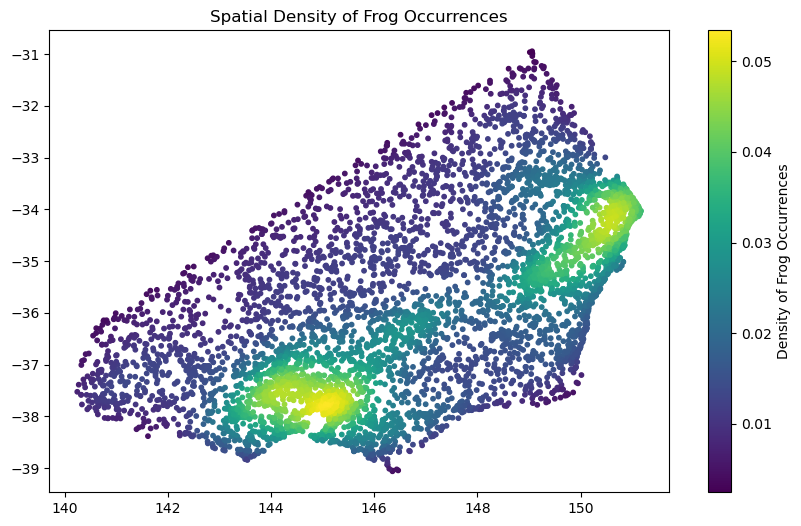

In [4]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
xy = np.vstack([combined_df["Longitude"], combined_df["Latitude"]])
z = gaussian_kde(xy)(xy)
plt.scatter(combined_df["Longitude"], combined_df["Latitude"], c=z, s=10, cmap="viridis")
plt.colorbar(label="Density of Frog Occurrences")
plt.title("Spatial Density of Frog Occurrences")
plt.show()


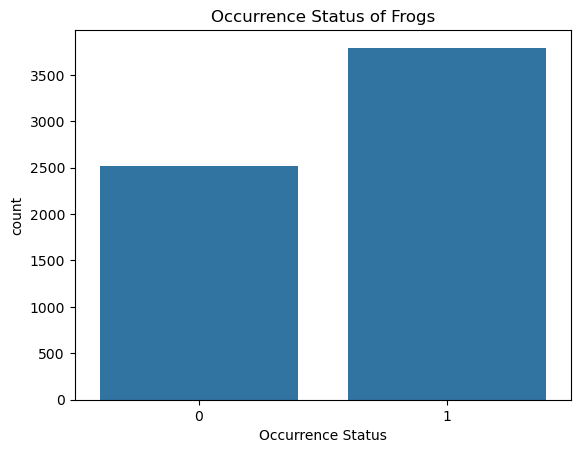

In [5]:
#bar graph for the Occurence status
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=combined_df['Occurrence Status'])
plt.title("Occurrence Status of Frogs")
plt.show()

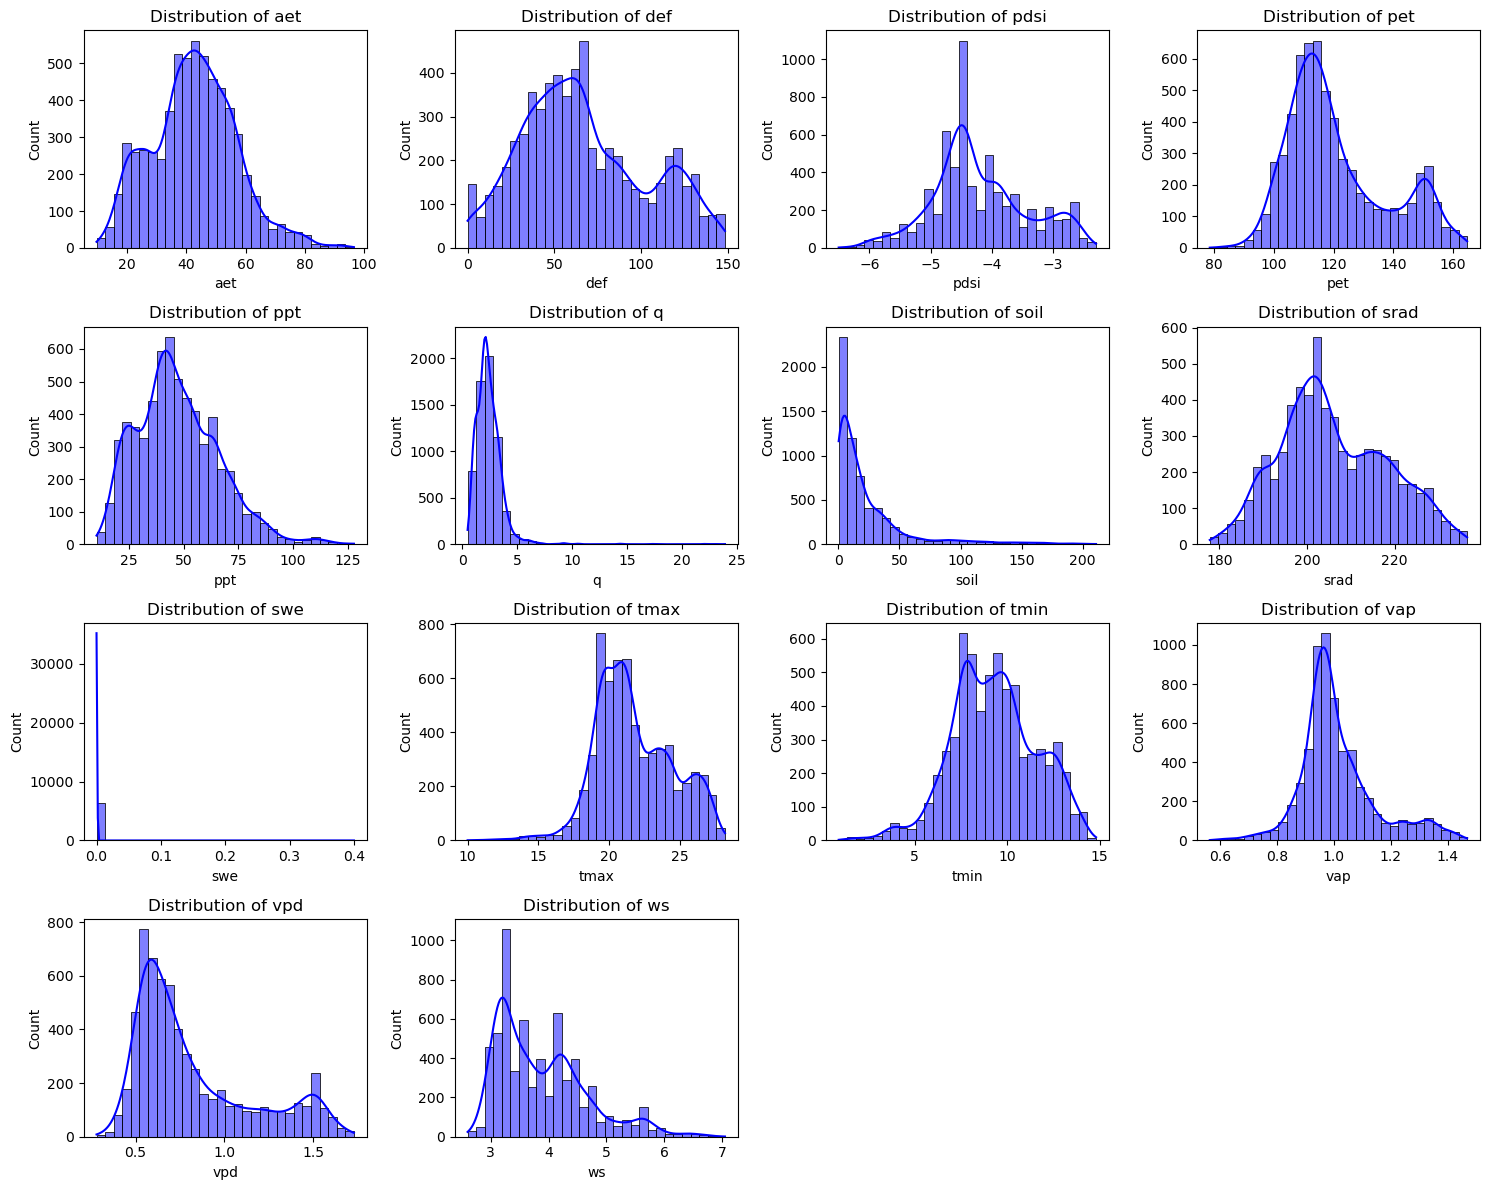

In [6]:
#Histogram for all the variables

import matplotlib.pyplot as plt
import seaborn as sns

# Define predictor variables (excluding Latitude, Longitude, and Target)
predictor_columns = combined_df.columns.difference(["Latitude", "Longitude", "Occurrence Status"])

# Set up the figure size
plt.figure(figsize=(15, 12))

# Loop through each predictor and create subplots
for i, col in enumerate(predictor_columns, 1):
    plt.subplot(4, 4, i)  # Adjust grid size based on the number of variables
    sns.histplot(combined_df[col], kde=True, bins=30, color="blue")
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

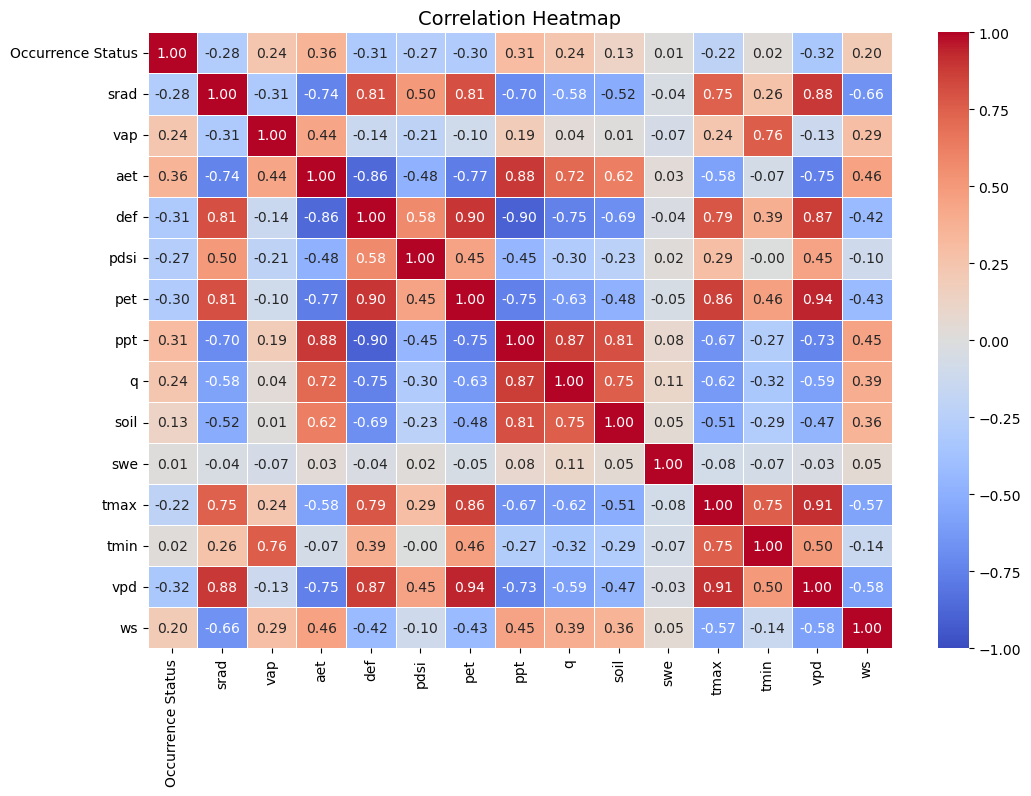

In [7]:
# Feature correlation

import seaborn as sns
import matplotlib.pyplot as plt

# Convert all columns to numeric in case some are still objects
final_data = combined_df.apply(pd.to_numeric, errors="coerce")

# Compute correlation matrix
corr_matrix = final_data.drop(columns=["Latitude", "Longitude"]).corr()


# Set up the figure size
plt.figure(figsize=(12, 8))

# Create the heatmap using seaborn
sns.heatmap(
    corr_matrix, 
    annot=True,   # Display correlation values
    fmt=".2f",    # Limit to 2 decimal places
    cmap="coolwarm",  # Color scheme
    linewidths=0.5,  # Add grid lines
    vmin=-1, vmax=1  # Set range of values
)

# Add a title
plt.title("Correlation Heatmap", fontsize=14)
plt.show()

#Some features will be highly correlated as they are derived from other variables. Check feature defination and calculation for the same.

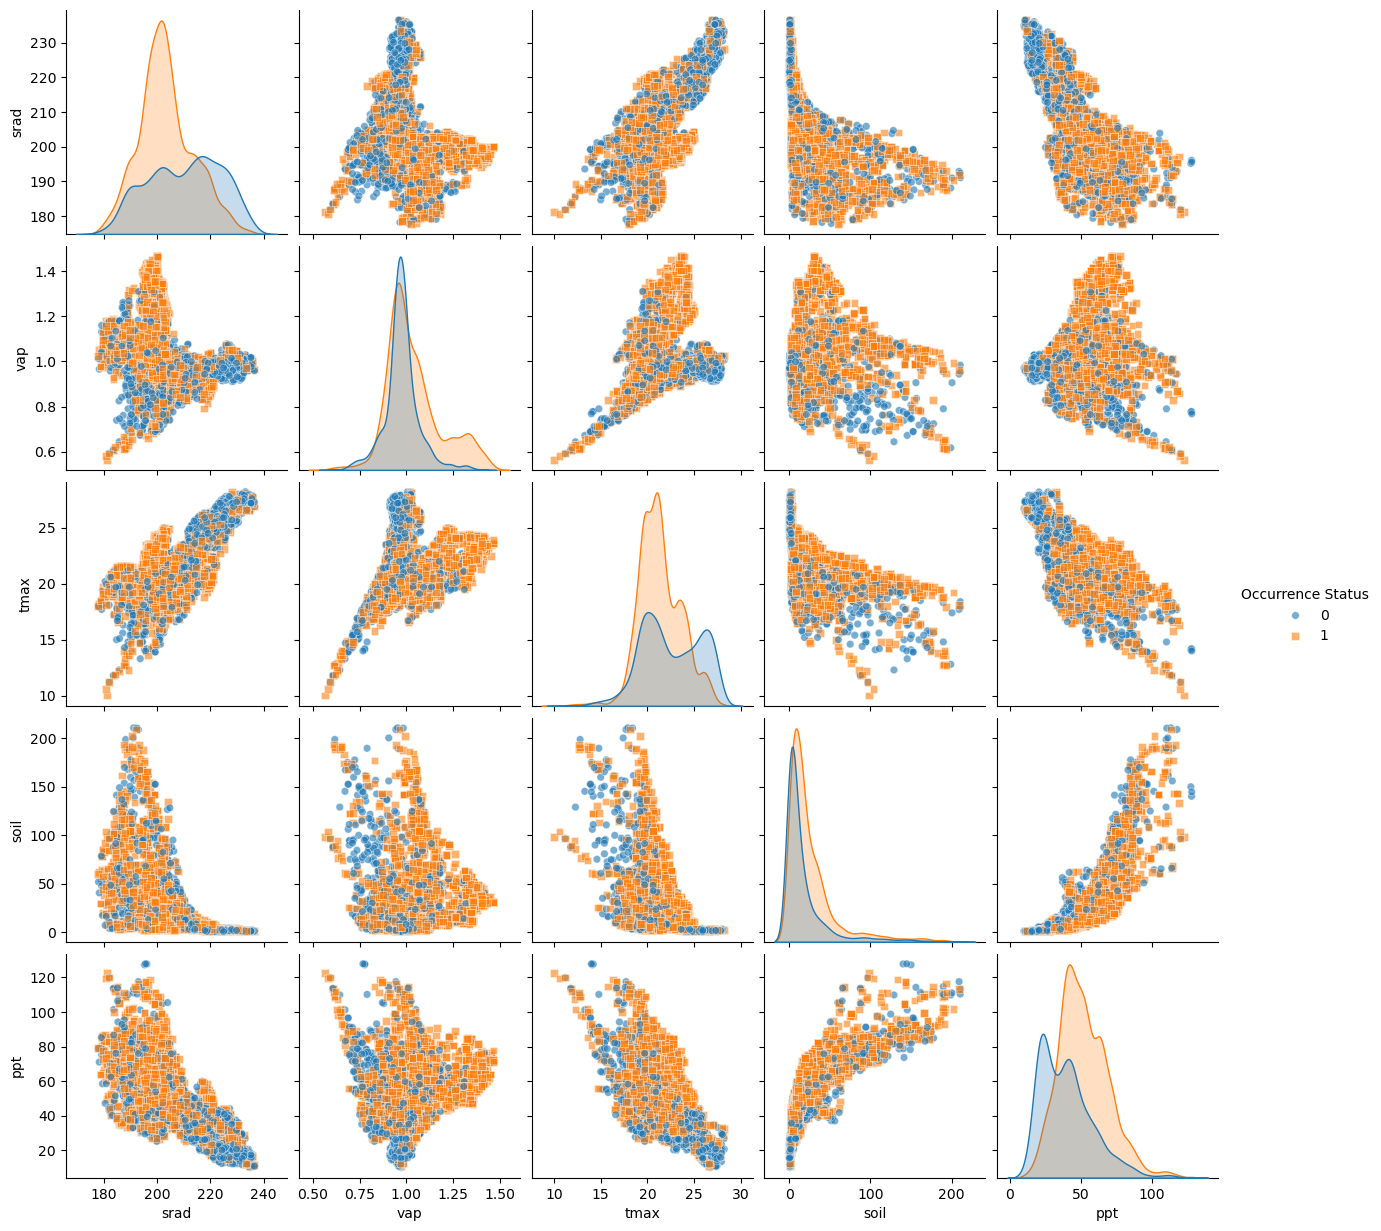

In [8]:
#Pair plot for important features:
#Plot is too cluttered for any useful inference, try seeing the trends and plot individually

important_features = ["Occurrence Status", "srad", "vap", "tmax", "soil", "ppt"]
#final_data[important_features] = final_data[important_features].apply(pd.to_numeric, errors="coerce")

import seaborn as sns
import matplotlib.pyplot as plt

# Select the subset of data
subset_data = combined_df[important_features]

# Create the pairplot with hue based on Occurrence Status
sns.pairplot(subset_data, hue="Occurrence Status", diag_kind="kde", markers=["o", "s"], plot_kws={'alpha': 0.6, "s": 30})

# Show the plot
plt.show()


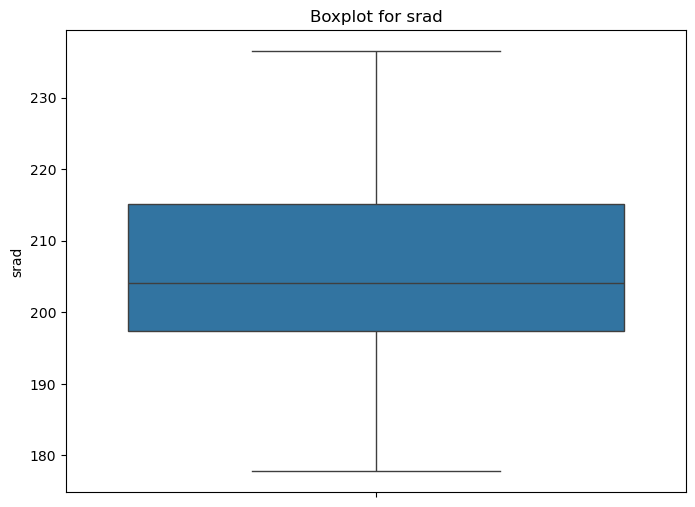

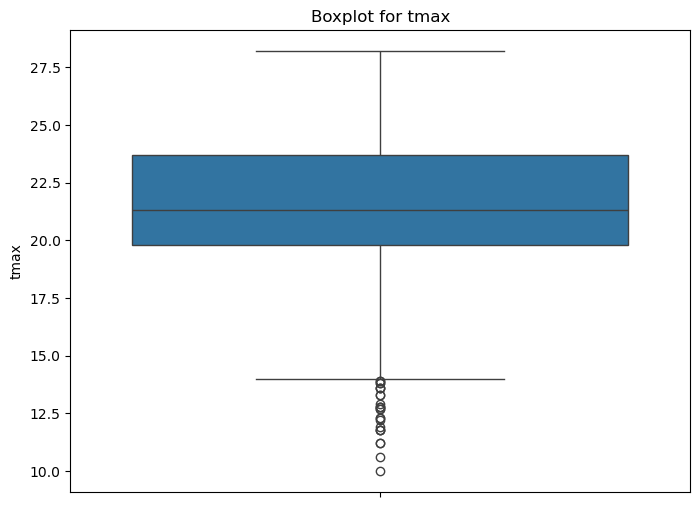

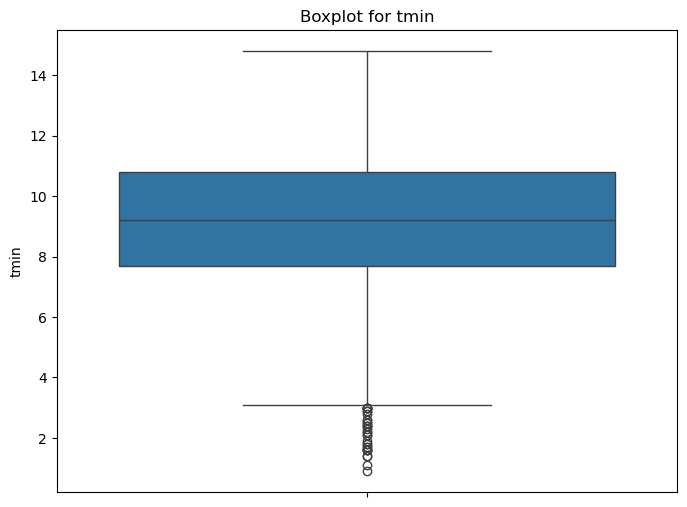

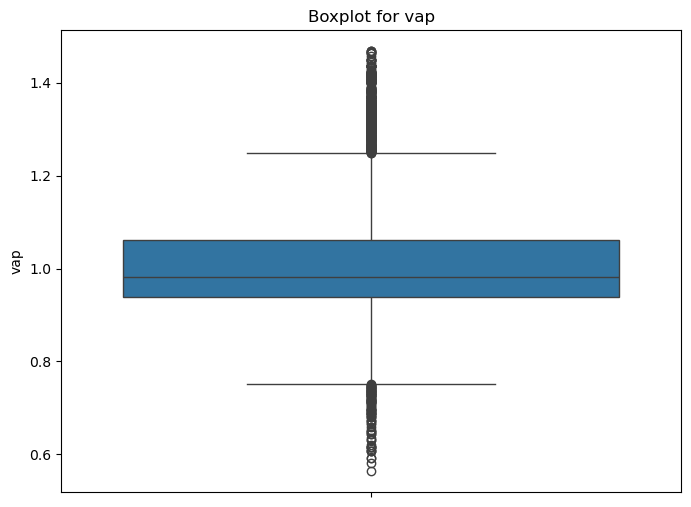

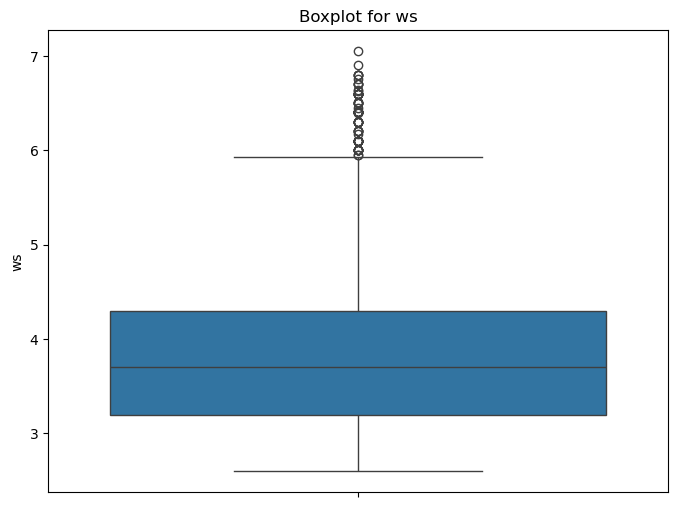

In [9]:
#boxplot for outlier detection

import seaborn as sns
import matplotlib.pyplot as plt

# List of numeric columns in the dataframe
columns = combined_df[['srad', 'tmax', 'tmin', 'vap', 'ws']]

# Create a boxplot for each variable
for col in columns:
    plt.figure(figsize=(8, 6))  # Define the figure size
    sns.boxplot(y=combined_df[col])  # Create the boxplot for each column
    plt.title(f'Boxplot for {col}')  # Title of each plot
    plt.show()  # Display the plot


In [10]:
#Z-score outlier detection

from scipy import stats
df_no_outliers = combined_df[(np.abs(stats.zscore(combined_df[['srad', 'tmax', 'tmin', 'vap', 'ws']])) < 3).all(axis=1)]
print("Rows before removing outliers:", len(combined_df))
print(f"Rows after removing outliers: {len(df_no_outliers)}")


Rows before removing outliers: 6312
Rows after removing outliers: 6180


In [ ]:
#next steps
#Feature Engineering Considerations
#Check for seasonality in variables like temperature, rainfall, etc.
#Transform skewed variables (log transformation if necessary).
#Create interaction terms between highly correlated predictors.

In [ ]:
#Check how features were created, use more features for the random forest model, save result.

In [ ]:
#6 primary measured parameters: ppt, srad, tmax, tmin, vap, ws.
